In [2]:
print('hello')

hello


---
# data

In [3]:
import modules.data as d
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device = u.Devices().auto_set_device()#drop=['cuda:4'])

#### data ####
brca = d.TCGA(
    tcga_project = 'BRCA',
    tcga_dir = dataset_dir/'tcga',
    # type_col = 'sample_type',
    subtype_col = 'paper_BRCA_Subtype_PAM50',
    drop = ['Normal', 'Primary Tumor', 'Metastatic'],
    gene_name_path = dataset_dir/'other'/'name2ensg.csv',
    keep_noname = False,
)

kegg = d.KEGG(
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv', 
    counts_data=brca,
) 

dataset = d.GraphDataset(brca, kegg, kegg)
_batch = d.get_toy_databatch(dataset, device)

('cuda:4', 'NVIDIA A100-SXM4-80GB', 81043)
('cuda:6', 'NVIDIA A100-SXM4-80GB', 81043)
('cuda:7', 'NVIDIA A100-SXM4-80GB', 81041)
('cuda:5', 'NVIDIA A100-SXM4-80GB', 74623)
('cuda:3', 'NVIDIA A100-SXM4-80GB', 63036)
('cuda:2', 'NVIDIA A100-SXM4-80GB', 46595)
('cuda:1', 'NVIDIA A100-SXM4-80GB', 45927)
('cuda:0', 'NVIDIA A100-SXM4-80GB', 38951)

# #### Device() ####
# device = cuda:4

# #### KEGG() ####
# _orig_kwargs             5                        dict
# relation                 (75939, 19)              DataFrame
# ensg                     4373                     list
# pathway_labels           305                      list
# edge_index               (2, 32464)               Tensor (cuda:4)
# edge_attr                (32464, 16)              Tensor (cuda:4)
# edge_labels              16                       list
# pathway_index            (4373, 305)              Tensor (cuda:4)

# #### TCGA() ####
# _orig_kwargs             9                        dict
# counts_path            

---
# model and output values

In [4]:
from modules.train import Loader
from modules.data import GraphDataset

from torch_geometric.loader import DataLoader
from modules.data import GraphDataset
from modules.utils import dict_summary
from collections import defaultdict

# typing
import torch
import torch.nn as nn
from torch import Tensor
from torch_geometric.data import Data, Batch


In [5]:
def load_model(model, state_dict_path:str, device:str, dataset:GraphDataset|None=None, batch_size:int=128):
    # init with loader
    init_fn = getattr(model, 'init_with_loader', None)
    if callable(init_fn) and dataset is not None:
        loader = Loader(dataset, device=device, batch_size=batch_size)
        init_fn(loader)

    # load state dict
    state_dict = torch.load(state_dict_path, map_location=device)
    model.load_state_dict(state_dict)

    # set model to eval
    model.eval()   

In [6]:
class ModelOut2():
    def __init__(self, model:nn.Module, dataset:GraphDataset, batch_size:int=64, **fwd_kwargs):
        fwd_kwargs = fwd_kwargs if fwd_kwargs is not None else {}

        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

        x_list = []
        y_list = []
        out_list = []

        for batch in loader:
            out = model(batch, **fwd_kwargs)
            out = self._detach_items(out)
            out_list.append(out)
            x_list.append(batch.x)
            y_list.append(batch.y)

        self.x = torch.cat(x_list, dim=0).reshape(-1, dataset.wrapper.num_nodes).cpu()
        self.y = torch.cat(y_list, dim=0).cpu()
        self.out = self._transpose_values(out_list)

    def _detach_items(self, item):
        # single tensor
        if isinstance(item, Tensor):
            return item.detach().cpu()

        # list/tuple (recursive)
        if isinstance(item, (list, tuple, set)):
            return type(item)(self._detach_items(i) for i in item)

        # dict, PyG Data/DataBatch
        if isinstance(item, (dict, Data, Batch)):
            return {key: self._detach_items(value) for key, value in item.items()}
        
        # other class with .x
        if hasattr(item, 'x'):
            return {
                'x': self._detach_items(item.x),
                'y': self._detach_items(getattr(item, 'y', None)),
                'sample_id': self._detach_items(getattr(item, 'sample_id', None))
            }
        
        # fallback
        return item

    def _transpose_values(self, values) -> dict:
        out = defaultdict(list)

        # collect
        for v in values:
            for k, val in v.items():
                out[k].append(val)

        # concat if tensor
        for k, vals in out.items():
            v0 = vals[0]

            if torch.is_tensor(v0):
                if v0.ndim == 0: # scalar tensor -> stack
                    out[k] = torch.stack(vals, dim=0)

                # elif v0.ndim == 1: # vector tensor -> concat

                else: # batched tensor -> concat on batch dim
                    out[k] = torch.cat(vals, dim=0)
            
            elif isinstance(v0, dict): # dict -> recursively concat
                out[k] = self._transpose_values(vals)

            else:
                out[k] = vals

        return dict(out) 

---
# viz

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from tqdm import tqdm

In [8]:
# for model
from modules.layers import AttentionSetPooling
from modules.model import MultiLatentModel
from modules.norm import LogCounts
from modules.train import MultiTrainer, MultiTrainerStage, Experiment, grid, Loader
from modules.trainers import ReconstrTrainer, ClassifTrainer
from modules.loss import NBLoss, KLDLoss, MultiLoss

import torch
import torch.nn as nn
from functools import partial

In [9]:
class AttnOut():
    def __init__(self, dataset, model_dirs:list[str], pathway_names_dir:str, mode:str['ae','cl']='ae'):
        self.dataset = dataset
        self.mode:str = mode

        # from dataset
        self.y_labels = dataset.wrapper.y_labels
        self.x_labels = dataset.wrapper.x_labels
        self.pathway_index = dataset.wrapper.pathway_index

        # pathway labels
        self.pathway_labels = [s.replace('path:', '') for s in dataset.wrapper.pathway_labels]
        self.pathway_names = pd.read_csv(pathway_names_dir, index_col=0).loc[self.pathway_labels, 'name'].str.replace(' - Homo sapiens (human)', '').to_list()

        # get values
        self._get_vals(model_dirs)

    def _get_vals(self, model_dirs:list[str]):
        joint_list:list = []
        split_list:dict[list] = {}

        for model_name in tqdm(model_dirs):
            # define model
            model = MultiLatentModel(
                dataset = self.dataset,
                embed_dim = 128,
                # head_dim = None (default)
                # num_heads = 1 (default)
                method = 'set',

                # layers
                norm_class = LogCounts,
                encoder_class = nn.Linear,
                pooling_class = AttentionSetPooling,
                mlp = False,
                variational = True,
                # out_module = nn.Linear (default)

                # layer params
                hidden_dims = 1,
                act_fn = nn.ReLU, 
                norm_fn = 'layer', 
                end_fn = False,

                # kwargs
                norm_kwargs = {'libnorm':True, 'znorm':True, 'learnable':True}
                # pooling_kwargs = None (default)
            )

            load_model(
                model=model,
                # state_dict_path=f'output/2026-01-20_18h51m04s_benchmark_2_attn/pathway_vae/{model_name}', # range = 5
                state_dict_path=model_name, # range = 30
                device=device,
                dataset=self.dataset,
            )

            # get output values
            vals = ModelOut2(model, self.dataset, need_weights=True)

            np = vals.out['layer_outs']['np']['attn'] # 1172,4373,305
            lp = vals.out['layer_outs'][f'lp_{self.mode}']['attn'].squeeze() # 1172,305
            joint = lp.unsqueeze(1) * np # 1172,4373,305
            split = {int(c): joint[vals.y == c] for c in torch.unique(vals.y)}

            # append to list
            joint_list.append(joint)
            for c, spl in split.items():
                if c not in split_list:
                    split_list[c] = []
                split_list[c].append(spl)

        # stack tensors
        self.joint = torch.stack(joint_list, dim=0) # num_trials, num_samples, num_pathways, embed_dim
        self.split = {c: torch.stack(spls, dim=0) for c, spls in split_list.items()}


In [10]:
model_dirs = [f'output/2026-04-22_21h44m56s_benchmark_2_attn/pathway_vae/pathway_vae_trial_{i}_model.pth' for i in range(3)]
out = AttnOut(
    dataset=dataset,
    model_dirs=model_dirs,
    pathway_names_dir=dataset_dir/'other'/'pathway_names.csv',
    mode='ae'
)

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:28<00:00,  9.47s/it]


In [11]:
out.joint.shape

torch.Size([3, 1172, 4373, 305])

In [12]:
out.split.keys()

dict_keys([0, 1, 2, 3, 4])

In [13]:
out.split[0].shape

torch.Size([3, 197, 4373, 305])

In [14]:
out.x_labels

['FGR',
 'GCLC',
 'NFYA',
 'SEMA3F',
 'CFTR',
 'CYP51A1',
 'KRIT1',
 'BAD',
 'LAP3',
 'AOC1',
 'M6PR',
 'CYP26B1',
 'ALS2',
 'CASP10',
 'CFLAR',
 'MTMR7',
 'SARM1',
 'AK2',
 'CD38',
 'KDM1A',
 'CAMKK1',
 'NDUFAB1',
 'PDK4',
 'CDC27',
 'HCCS',
 'DVL2',
 'UPF1',
 'SLC25A5',
 'DHX33',
 'ACSM3',
 'PRKAR2B',
 'CREBBP',
 'KMT2E',
 'ZNF195',
 'ITGAL',
 'PDK2',
 'ITGA3',
 'LAMP2',
 'ITGA2B',
 'MAP3K14',
 'ABCC8',
 'AP2B1',
 'CX3CL1',
 'CACNA1G',
 'TNFRSF12A',
 'MAP3K9',
 'RALA',
 'AGK',
 'ALDH3B1',
 'FARP2',
 'GGCT',
 'TBXA2R',
 'COX10',
 'VPS41',
 'SCIN',
 'PNPLA4',
 'ADIPOR2',
 'PAFAH1B1',
 'DNAH9',
 'MATK',
 'CD79B',
 'RHBDF1',
 'CACNA2D2',
 'TEAD3',
 'SELE',
 'FMO3',
 'MYLIP',
 'NOX1',
 'E2F2',
 'PSMB1',
 'NADK',
 'CYTH3',
 'AASS',
 'MGST1',
 'ST3GAL1',
 'MMP25',
 'MAPK8IP2',
 'MASP2',
 'POMT2',
 'VTA1',
 'MLXIPL',
 'UQCRC1',
 'GIPR',
 'SEMA3G',
 'STAB1',
 'IDS',
 'ZNF200',
 'CD4',
 'BTK',
 'HFE',
 'FYN',
 'FMO1',
 'LYPLA2',
 'MRC2',
 'ABHD5',
 'PIK3C2A',
 'PLAUR',
 'DCN',
 'PPP5C',
 'MAP4

In [15]:
out.y_labels

['Basal', 'Her2', 'LumA', 'LumB', 'Solid Tissue Normal']

In [16]:
out.pathway_names

['Fat digestion and absorption',
 'MAPK signaling pathway',
 'JAK-STAT signaling pathway',
 'Cocaine addiction',
 'Colorectal cancer',
 'Mitophagy - animal',
 'Epstein-Barr virus infection',
 'Oocyte meiosis',
 'Proteoglycans in cancer',
 'Adherens junction',
 'Autoimmune thyroid disease',
 'Fc gamma R-mediated phagocytosis',
 'Valine, leucine and isoleucine degradation',
 'Intestinal immune network for IgA production',
 'Allograft rejection',
 'FoxO signaling pathway',
 'Arrhythmogenic right ventricular cardiomyopathy',
 'TNF signaling pathway',
 'Amino sugar and nucleotide sugar metabolism',
 'Viral protein interaction with cytokine and cytokine receptor',
 'Vitamin B6 metabolism',
 'Glycosylphosphatidylinositol (GPI)-anchor biosynthesis',
 'Inflammatory bowel disease',
 'Neutrophil extracellular trap formation',
 'alpha-Linolenic acid metabolism',
 'Cholesterol metabolism',
 'Hedgehog signaling pathway',
 'Pyrimidine metabolism',
 'Renin-angiotensin system',
 'Pentose phosphate path

In [17]:
out.pathway_index.shape

torch.Size([4373, 305])

In [ ]:
def rank_pathways(
    joint: torch.Tensor,            # (trials, samples, genes, pathways)
    split: dict,                    # class -> (trials, samples_in_class, genes, pathways)
    pathway_names: list[str],
    y_labels: list[str],
    pathway_index: torch.Tensor,    # (genes, pathways)
    balanced: bool = True,
    frac: float = 0.3,
    eps: float = 1e-8,
):
    # class means
    class_trial_means = {}
    class_means = []

    for class_idx, tensor in split.items():

        # get class name from label
        class_name = y_labels[class_idx]

        # sum across genes: (trials, samples_c, pathways) -> mean across samples: (trials, pathways)
        class_trial_mean = tensor.sum(dim=2).mean(dim=1)   

        # store means for later
        class_trial_means[class_name] = class_trial_mean
        class_means.append(class_trial_mean.mean(dim=0)) # (pathways,)

    # global mean & df
    if balanced:
        # (trials, pathways) -> mean across trials: (pathways,)
        global_mean = torch.stack(class_means, dim=0).mean(dim=0) # (pathways,)

        # (classes, trials, pathways) -> mean across classes: (trials, pathways) -> std across trials: (pathways,)
        global_std = torch.stack([v for v in class_trial_means.values()], dim=0).mean(dim=0).std(dim=0, unbiased=False)

    else:
        # sum across genes: (trials, samples, pathways) -> mean across samples: (trials, pathways)
        trial_means = joint.sum(dim=2).mean(dim=1) # (trials, pathways)

        # mean/std across trials: (pathways,)
        global_mean = trial_means.mean(dim=0)
        global_std = trial_means.std(dim=0, unbiased=False)

    # build dataframe
    df = pd.DataFrame({
        "pathway": pathway_names,
        "n_genes": pathway_index.sum(dim=0).detach().cpu().numpy(), # sum across genes: (pathways,)
        "global_mean": global_mean.detach().cpu().numpy(),
        "global_std": global_std.detach().cpu().numpy(),
    })

    # add class-specific mean columns
    for class_name, class_trial_mean in class_trial_means.items():
        df[f"{class_name}_mean"] = (
            class_trial_mean.mean(dim=0).detach().cpu().numpy()
        )

    # lowess size correction
    df["lowess_expected"] = sm.nonparametric.lowess(
        df["global_mean"].values, # y
        df["n_genes"].values, # x
        frac=frac,
        return_sorted=False
    )
    df["lowess_resid"] = df["global_mean"] - df["lowess_expected"]
    df["score"] = df["lowess_resid"] / (df["global_std"] + eps)

    return df

In [65]:
df = rank_pathways(
    joint=out.joint,
    split=out.split,
    pathway_names=out.pathway_names,
    y_labels=out.y_labels,
    pathway_index=out.pathway_index
)
df

,pathway,n_genes,global_mean,global_std,Basal_mean,Her2_mean,LumA_mean,LumB_mean,Solid Tissue Normal_mean,lowess_expected,lowess_resid,score
0,Fat digestion and absorption,8.0,0.003731,0.000310,0.003709,0.003617,0.003735,0.003753,0.003844,0.003437,0.000294,0.950839
1,MAPK signaling pathway,261.0,0.002881,0.000561,0.002867,0.002854,0.002899,0.002873,0.002912,0.003010,-0.000129,-0.229827
2,JAK-STAT signaling pathway,36.0,0.002749,0.000420,0.002711,0.002792,0.002734,0.002776,0.002729,0.003294,-0.000546,-1.299021
3,Cocaine addiction,28.0,0.003447,0.000486,0.003496,0.003432,0.003386,0.003406,0.003516,0.003304,0.000143,0.294932
4,Colorectal cancer,67.0,0.002790,0.000245,0.002736,0.002816,0.002832,0.002806,0.002760,0.003178,-0.000388,-1.585653
...,...,...,...,...,...,...,...,...,...,...,...,...
300,B cell receptor signaling pathway,72.0,0.003478,0.000485,0.003522,0.003454,0.003419,0.003453,0.003542,0.003178,0.000299,0.617498
301,Pyruvate metabolism,35.0,0.003103,0.000492,0.003052,0.003012,0.003190,0.003040,0.003220,0.003295,-0.000192,-0.391201
302,"Parathyroid hormone synthesis, secretion and a...",82.0,0.003399,0.000431,0.003400,0.003388,0.003382,0.003391,0.003431,0.003166,0.000232,0.538706
303,Glucagon signaling pathway,52.0,0.003498,0.000313,0.003532,0.003523,0.003482,0.003526,0.003428,0.003237,0.000261,0.836355


In [130]:
df.sort_values("global_mean", ascending=False).tail(20)

,pathway,n_genes,global_mean,global_std,Basal_mean,Her2_mean,LumA_mean,LumB_mean,Solid Tissue Normal_mean,lowess_expected,lowess_resid,score,Basal_enrichment,LumA_enrichment,rank_raw,rank_resid
140,Prolactin signaling pathway,58.0,0.002802,0.000550,0.002816,0.002796,0.002766,0.002796,0.002837,0.003202,-0.000400,-0.727616,0.000014,-0.000037,286.0,286.0
248,Mannose type O-glycan biosynthesis,22.0,0.002800,0.000254,0.002718,0.002835,0.002835,0.002745,0.002864,0.003361,-0.000561,-2.207911,-0.000082,0.000036,287.0,301.0
4,Colorectal cancer,67.0,0.002790,0.000245,0.002736,0.002816,0.002832,0.002806,0.002760,0.003178,-0.000388,-1.585653,-0.000054,0.000042,288.0,281.0
142,Shigellosis,152.0,0.002782,0.000359,0.002730,0.002802,0.002848,0.002807,0.002723,0.003033,-0.000251,-0.698773,-0.000052,0.000066,289.0,250.0
131,"Growth hormone synthesis, secretion and action",95.0,0.002780,0.000422,0.002747,0.002778,0.002790,0.002786,0.002799,0.003133,-0.000353,-0.835332,-0.000033,0.000011,290.0,276.0
264,Glioma,64.0,0.002773,0.000453,0.002742,0.002798,0.002799,0.002786,0.002739,0.003183,-0.000411,-0.906022,-0.000031,0.000026,291.0,288.0
181,Platinum drug resistance,38.0,0.002766,0.000359,0.002724,0.002716,0.002839,0.002770,0.002779,0.003291,-0.000525,-1.461520,-0.000042,0.000074,292.0,297.0
79,AGE-RAGE signaling pathway in diabetic complic...,86.0,0.002754,0.000391,0.002731,0.002772,0.002768,0.002763,0.002734,0.003153,-0.000399,-1.020172,-0.000023,0.000015,293.0,285.0
128,Salmonella infection,144.0,0.002753,0.000511,0.002770,0.002759,0.002746,0.002751,0.002739,0.003048,-0.000295,-0.577456,0.000017,-0.000007,294.0,261.0
2,JAK-STAT signaling pathway,36.0,0.002749,0.000420,0.002711,0.002792,0.002734,0.002776,0.002729,0.003294,-0.000546,-1.299021,-0.000037,-0.000014,295.0,299.0


---
## lowess plots

In [67]:
# fig, ax = plt.subplots(figsize=(10,6))
# sns.scatterplot(data=df, x="n_genes", y="global_mean", ax=ax)
# sns.lineplot(data=df, x="n_genes", y="lowess_expected", ax=ax, color='red')
# ax.legend(
#     handles=[ax.collections[0], ax.lines[0]], 
#     labels=["Global mean", "LOWESS expected"], 
#     loc="best"
# )
# plt.show()

# fig, ax = plt.subplots(figsize=(10,6))
# sns.scatterplot(data=df, x="n_genes", y="lowess_resid", ax=ax)
# plt.axhline(0, color='red', linestyle='--')
# plt.show()

# fig, ax = plt.subplots(figsize=(10,6))
# sns.scatterplot(data=df, x="n_genes", y="score", ax=ax)
# plt.axhline(0, color='red', linestyle='--')
# plt.show()

In [68]:
# sns.displot(df, x="global_mean", kde=True)
# plt.show()

# sns.displot(df, x="lowess_resid", kde=True)
# plt.show()

# sns.displot(df, x="score", kde=True)
# plt.show()

---

In [69]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# from adjustText import adjust_text


# def plot_lowess_fit(df):
#     plt.figure(figsize=(7, 5))

#     sns.scatterplot(
#         data=df,
#         x="n_genes",
#         y="global_mean",
#         alpha=0.6
#     )

#     order = df.sort_values("n_genes")

#     plt.plot(
#         order["n_genes"],
#         order["lowess_expected"],
#         linewidth=2
#     )

#     plt.xlabel("Number of genes in pathway")
#     plt.ylabel("Global mean pathway attention")
#     plt.title("Pathway attention vs pathway size")
#     plt.tight_layout()
#     plt.show()

# def plot_top_residuals(df, top_k=25):
#     plot_df = df.sort_values("lowess_resid", ascending=False).head(top_k)

#     plt.figure(figsize=(8, 0.35 * top_k + 2))

#     sns.barplot(
#         data=plot_df,
#         x="lowess_resid",
#         y="pathway"
#     )

#     plt.axvline(0, linestyle="--", linewidth=1)
#     plt.xlabel("LOWESS residual")
#     plt.ylabel("")
#     plt.title(f"Top {top_k} size-adjusted pathways")
#     plt.tight_layout()
#     plt.show()

# def plot_top_scores(df, top_k=25):
#     plot_df = df.sort_values("score", ascending=False).head(top_k)

#     plt.figure(figsize=(8, 0.35 * top_k + 2))

#     sns.barplot(
#         data=plot_df,
#         x="score",
#         y="pathway"
#     )

#     plt.axvline(0, linestyle="--", linewidth=1)
#     plt.xlabel("LOWESS residual / trial std")
#     plt.ylabel("")
#     plt.title(f"Top {top_k} stable size-adjusted pathways")
#     plt.tight_layout()
#     plt.show()

# df = rank_pathways(
#     joint=out.joint,
#     split=out.split,
#     pathway_names=out.pathway_names,
#     y_labels=out.y_labels,
#     pathway_index=out.pathway_index,
#     balanced=True,
# )

# def plot_lowess_fit_labeled(df, top_k=10):
#     plt.figure(figsize=(8, 6))

#     sns.scatterplot(
#         data=df,
#         x="n_genes",
#         y="global_mean",
#         alpha=0.5
#     )

#     order = df.sort_values("n_genes")

#     plt.plot(
#         order["n_genes"],
#         order["lowess_expected"],
#         linewidth=2
#     )

#     top = df.sort_values("score", ascending=False).head(top_k)

#     texts = []
#     for _, row in top.iterrows():
#         texts.append(
#             plt.text(
#                 row["n_genes"],
#                 row["global_mean"],
#                 row["pathway"],
#                 fontsize=8
#             )
#         )
        
#     # adjust overlap
#     adjust_text(
#         texts,
#         arrowprops=dict(arrowstyle="-", lw=0.5),
#     )

#     plt.xlabel("Number of genes in pathway")
#     plt.ylabel("Global mean pathway attention")
#     plt.title("LOWESS size correction with top-ranked pathways")
#     plt.tight_layout()
#     plt.show()

# plot_lowess_fit(df)
# plot_lowess_fit_labeled(df, top_k=10)
# plot_top_residuals(df, top_k=25)
# plot_top_scores(df, top_k=25)

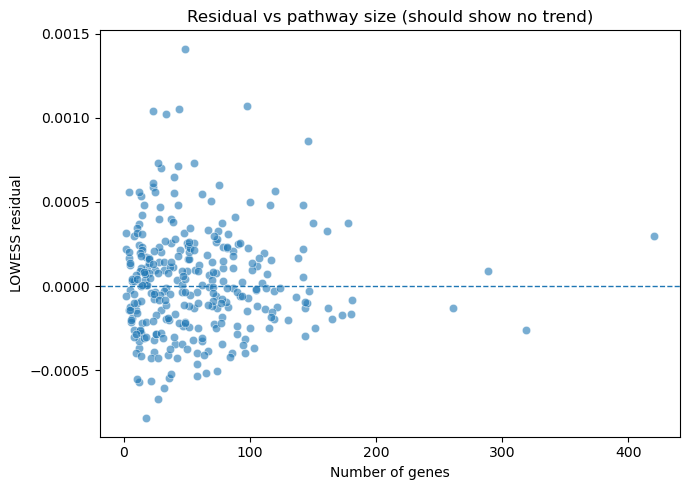

In [70]:
def plot_residual_vs_size(df):
    plt.figure(figsize=(7, 5))

    sns.scatterplot(
        data=df,
        x="n_genes",
        y="lowess_resid",
        alpha=0.6
    )

    plt.axhline(0, linestyle="--", linewidth=1)

    plt.xlabel("Number of genes")
    plt.ylabel("LOWESS residual")
    plt.title("Residual vs pathway size (should show no trend)")
    plt.tight_layout()
    plt.show()

plot_residual_vs_size(df)

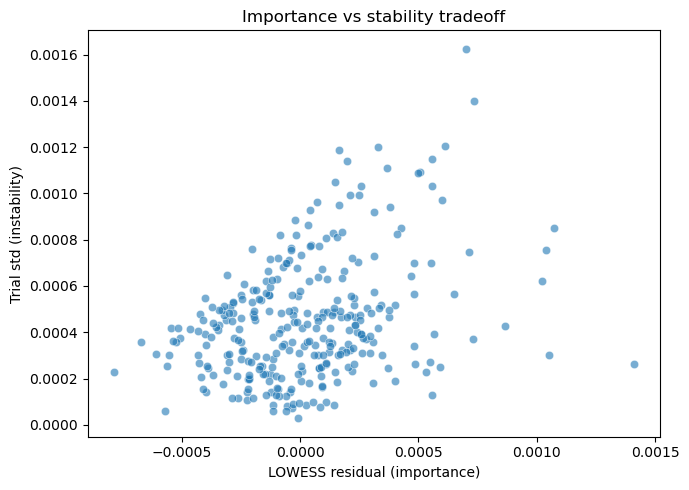

In [71]:
def plot_stability_vs_residual(df):
    plt.figure(figsize=(7, 5))

    sns.scatterplot(
        data=df,
        x="lowess_resid",
        y="global_std",
        alpha=0.6
    )

    plt.xlabel("LOWESS residual (importance)")
    plt.ylabel("Trial std (instability)")
    plt.title("Importance vs stability tradeoff")
    plt.tight_layout()
    plt.show()

plot_stability_vs_residual(df)

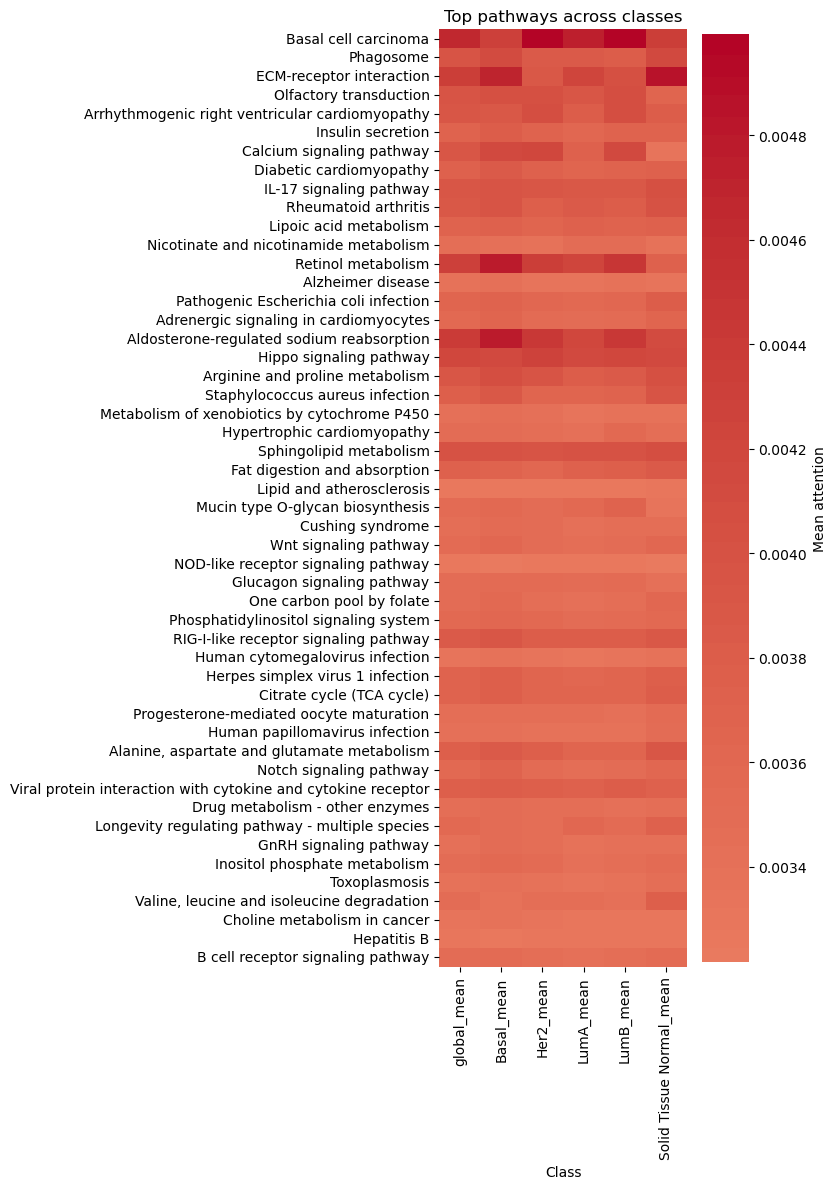

In [78]:
def plot_class_heatmap(df, top_k=25):
    class_cols = [c for c in df.columns if c.endswith("_mean")]

    plot_df = (
        df.sort_values("score", ascending=False)
          .head(top_k)
          .set_index("pathway")[class_cols]
    )

    plt.figure(figsize=(8, 0.2 * top_k + 2))

    sns.heatmap(
        plot_df,
        center=0,
        cmap="coolwarm",
        cbar_kws={"label": "Mean attention"}
    )

    plt.title("Top pathways across classes")
    plt.xlabel("Class")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

plot_class_heatmap(df, top_k=50)

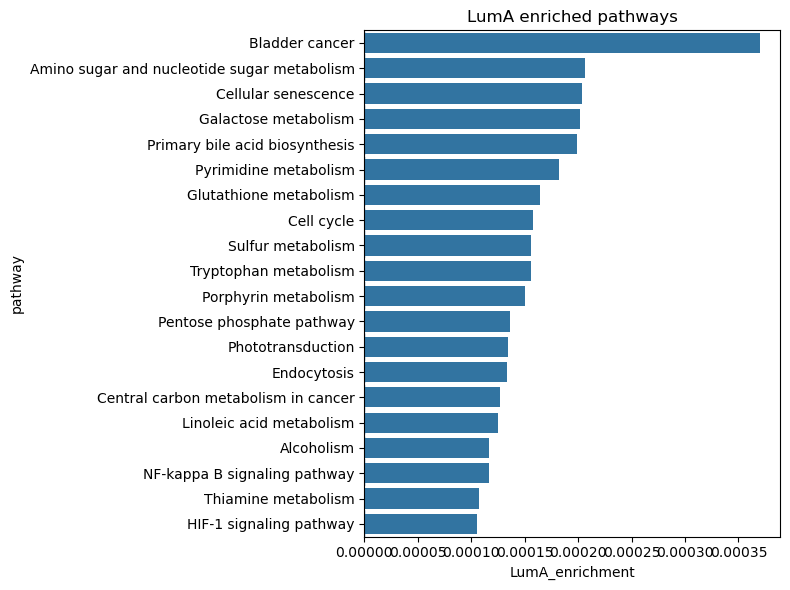

In [86]:
def plot_class_enrichment(df, class_name, top_k=20):
    col = f"{class_name}_mean"

    df[f"{class_name}_enrichment"] = df[col] - df["global_mean"]

    plot_df = df.sort_values(
        f"{class_name}_enrichment",
        ascending=False
    ).head(top_k)

    plt.figure(figsize=(8, 0.2 * top_k + 2))

    sns.barplot(
        data=plot_df,
        x=f"{class_name}_enrichment",
        y="pathway"
    )

    plt.axvline(0, linestyle="--", linewidth=1)

    plt.title(f"{class_name} enriched pathways")
    plt.tight_layout()
    plt.show()

plot_class_enrichment(df, 'LumA', top_k=20)

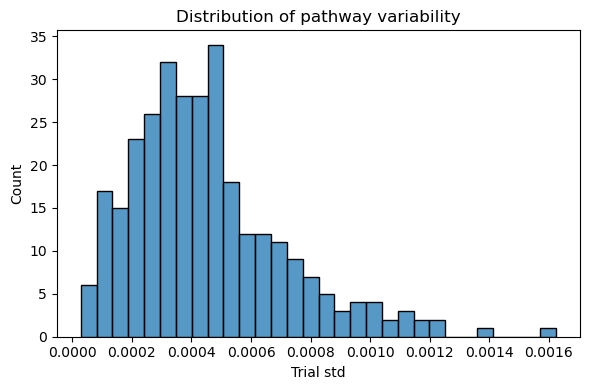

In [88]:
def plot_std_distribution(df):
    plt.figure(figsize=(6, 4))

    sns.histplot(df["global_std"], bins=30)

    plt.xlabel("Trial std")
    plt.title("Distribution of pathway variability")
    plt.tight_layout()
    plt.show()

plot_std_distribution(df)

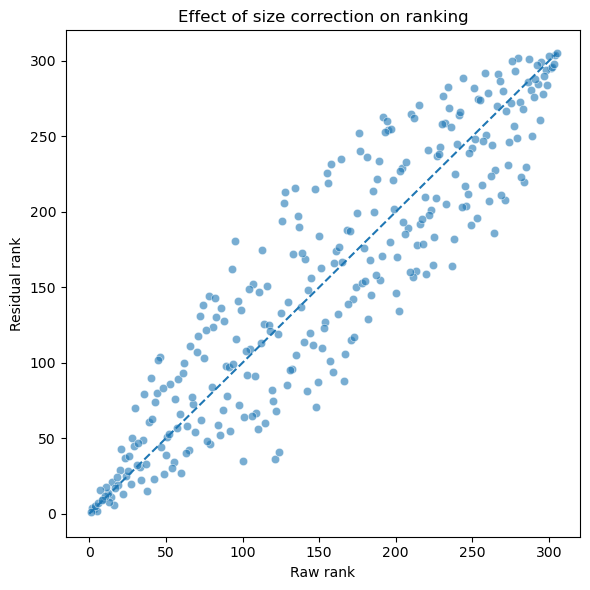

In [89]:
def plot_rank_comparison(df):
    df["rank_raw"] = df["global_mean"].rank(ascending=False)
    df["rank_resid"] = df["lowess_resid"].rank(ascending=False)

    plt.figure(figsize=(6, 6))

    sns.scatterplot(
        data=df,
        x="rank_raw",
        y="rank_resid",
        alpha=0.6
    )

    plt.plot([0, len(df)], [0, len(df)], linestyle="--")

    plt.xlabel("Raw rank")
    plt.ylabel("Residual rank")
    plt.title("Effect of size correction on ranking")
    plt.tight_layout()
    plt.show()

plot_rank_comparison(df)

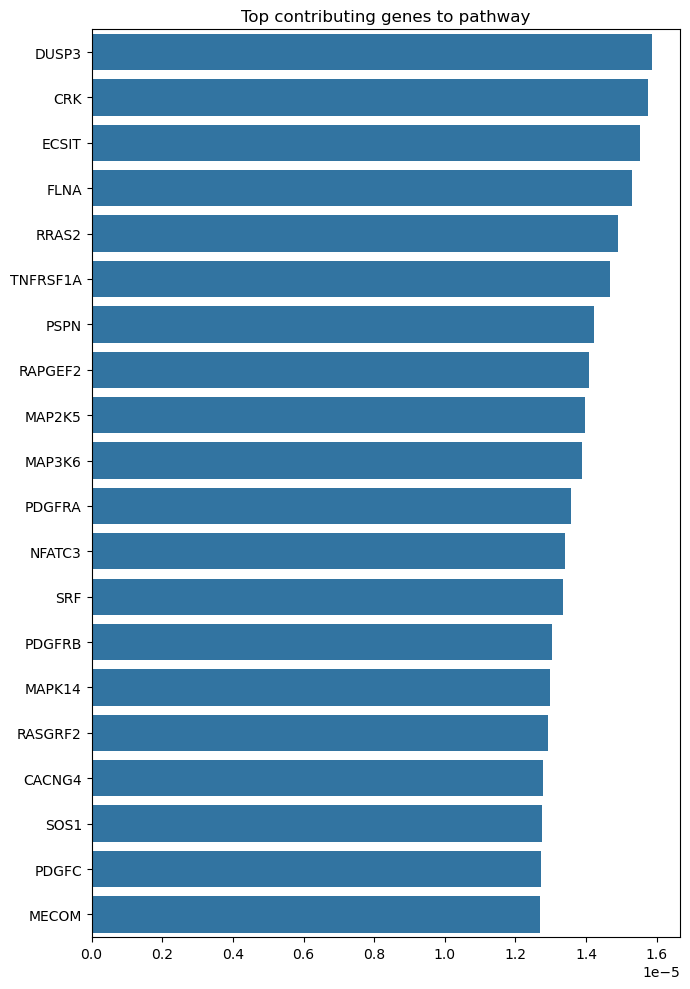

In [91]:
def plot_gene_contributions(attn_tensor, pathway_idx, gene_names, top_k=20):
    # average across trials and samples
    gene_scores = attn_tensor.mean(dim=(0, 1))[:, pathway_idx]

    values, indices = torch.topk(gene_scores, top_k)

    genes = [gene_names[i] for i in indices.cpu().numpy()]

    plt.figure(figsize=(7, 0.4 * top_k + 2))

    sns.barplot(
        x=values.cpu().numpy(),
        y=genes
    )

    plt.title("Top contributing genes to pathway")
    plt.tight_layout()
    plt.show()

plot_gene_contributions(out.joint, pathway_idx=1, gene_names=out.x_labels, top_k=20)

---

In [139]:
def get_rankings(
    joint: torch.Tensor,            # (trials, samples, genes, pathways)
    split: dict,                    # class -> (trials, samples_in_class, genes, pathways)
    gene_labels: list[str],
    class_labels: list[str],
    pathway_names: list[str],
    pathway_index: torch.Tensor,    # (genes, pathways)
    level: str['pathway', 'gene'] = 'pathway',
    balanced: bool = True,
    frac: float = 0.3,
    eps: float = 1e-8,
):
    # sum on genes if pathway, else sum on pathways if gene
    sum_means_on = 2 if level == 'pathway' else 3
    sum_idx_on = 0 if level == 'pathway' else 1
    
    # class means
    class_trial_means = {}
    class_means = []

    for class_idx, tensor in split.items():
        # get class name from label
        class_name = class_labels[class_idx]

        # sum across genes: (trials, samples_c, pathways) -> mean across samples: (trials, pathways)
        class_trial_mean = tensor.sum(dim=sum_means_on).mean(dim=1)   

        # store means for later
        class_trial_means[class_name] = class_trial_mean
        class_means.append(class_trial_mean.mean(dim=0)) # (pathways,)

    # global mean & df
    if balanced:
        # (trials, pathways) -> mean across trials: (pathways,)
        global_mean = torch.stack(class_means, dim=0).mean(dim=0) # (pathways,)

        # (classes, trials, pathways) -> mean across classes: (trials, pathways) -> std across trials: (pathways,)
        global_std = torch.stack([v for v in class_trial_means.values()], dim=0).mean(dim=0).std(dim=0, unbiased=False)

    else:
        # sum across genes: (trials, samples, pathways) -> mean across samples: (trials, pathways)
        trial_means = joint.sum(dim=sum_means_on).mean(dim=1) # (trials, pathways)

        # mean/std across trials: (pathways,)
        global_mean = trial_means.mean(dim=0)
        global_std = trial_means.std(dim=0, unbiased=False)

    # build dataframe
    df = pd.DataFrame({
        "name": pathway_names if level == 'pathway' else gene_labels,
        "n": pathway_index.sum(dim=sum_idx_on).detach().cpu().numpy(), # sum across genes: (pathways,)
        "global_mean": global_mean.detach().cpu().numpy(),
        "global_std": global_std.detach().cpu().numpy(),
    })

    # add class-specific mean columns
    for class_name, class_trial_mean in class_trial_means.items():
        df[f"{class_name}_mean"] = (
            class_trial_mean.mean(dim=0).detach().cpu().numpy()
        )

    # lowess size correction
    if level == 'gene': # add jitter to remove duplicate values warning
        x = df["n"].values + np.random.normal(0, 1e-8, size=df["n"].values.shape)
    else:
        x = df["n"].values

    df["lowess_expected"] = sm.nonparametric.lowess(
        df["global_mean"].values, # y
        x,
        frac=frac,
        return_sorted=False
    )
    df["lowess_resid"] = df["global_mean"] - df["lowess_expected"]
    df["score"] = df["lowess_resid"] / (df["global_std"] + eps)

    return df

In [142]:
df2 = get_rankings(
    joint=out.joint,
    split=out.split,
    gene_labels=out.x_labels,
    class_labels=out.y_labels,
    pathway_names=out.pathway_names,
    pathway_index=out.pathway_index,
    level='gene',
)

df2

,name,n,global_mean,global_std,Basal_mean,Her2_mean,LumA_mean,LumB_mean,Solid Tissue Normal_mean,lowess_expected,lowess_resid,score
0,FGR,1.0,0.000020,0.000002,0.000020,0.000021,0.000021,0.000019,0.000021,0.000053,-0.000033,-16.268670
1,GCLC,2.0,0.000170,0.000023,0.000169,0.000167,0.000169,0.000169,0.000177,0.000109,0.000061,2.651522
2,NFYA,3.0,0.000182,0.000029,0.000178,0.000198,0.000187,0.000202,0.000146,0.000136,0.000046,1.598967
3,SEMA3F,1.0,0.000019,0.000009,0.000018,0.000019,0.000018,0.000021,0.000020,0.000053,-0.000034,-3.940981
4,CFTR,5.0,0.000653,0.000103,0.000566,0.000571,0.000735,0.000843,0.000550,0.000188,0.000465,4.536467
...,...,...,...,...,...,...,...,...,...,...,...,...
4368,ZNF229,1.0,0.000010,0.000002,0.000011,0.000009,0.000008,0.000008,0.000012,0.000054,-0.000044,-29.335418
4369,ACACA,7.0,0.000596,0.000033,0.000516,0.000637,0.000617,0.000650,0.000558,0.000267,0.000329,9.946529
4370,H3C10,1.0,0.000017,0.000002,0.000017,0.000021,0.000019,0.000022,0.000006,0.000053,-0.000036,-15.449029
4371,ADORA3,2.0,0.000060,0.000003,0.000042,0.000067,0.000071,0.000075,0.000043,0.000109,-0.000050,-14.366570


In [128]:
df2.sort_values("score", ascending=False).head(20)

,name,n,global_mean,global_std,Basal_mean,Her2_mean,LumA_mean,LumB_mean,Solid Tissue Normal_mean,lowess_expected,lowess_resid,score
277,Basal cell carcinoma,49.0,0.004672,0.000262,0.004321,0.004995,0.004734,0.004976,0.004336,0.003263,0.001409,5.375531
78,Phagosome,12.0,0.003962,0.000129,0.004124,0.003847,0.003862,0.003805,0.004173,0.003406,0.000556,4.298041
49,ECM-receptor interaction,44.0,0.004341,0.000304,0.004710,0.003868,0.004239,0.004046,0.004841,0.003288,0.001053,3.465602
59,Olfactory transduction,23.0,0.003942,0.000249,0.004022,0.004023,0.003924,0.004092,0.003648,0.003353,0.000589,2.368266
16,Arrhythmogenic right ventricular cardiomyopathy,14.0,0.003930,0.000229,0.003876,0.004072,0.003821,0.004088,0.003793,0.003398,0.000532,2.325579
33,Insulin secretion,38.0,0.003691,0.000191,0.003811,0.003691,0.003594,0.003673,0.003688,0.003291,0.000401,2.095080
219,Calcium signaling pathway,146.0,0.003908,0.000428,0.004138,0.004176,0.003737,0.004158,0.003331,0.003044,0.000864,2.019312
156,Diabetic cardiomyopathy,62.0,0.003737,0.000272,0.003850,0.003736,0.003663,0.003709,0.003725,0.003189,0.000547,2.013277
224,IL-17 signaling pathway,56.0,0.003936,0.000373,0.003965,0.003918,0.003884,0.003878,0.004034,0.003207,0.000729,1.955527
270,Rheumatoid arthritis,16.0,0.003878,0.000263,0.003974,0.003773,0.003840,0.003797,0.004007,0.003394,0.000484,1.836607


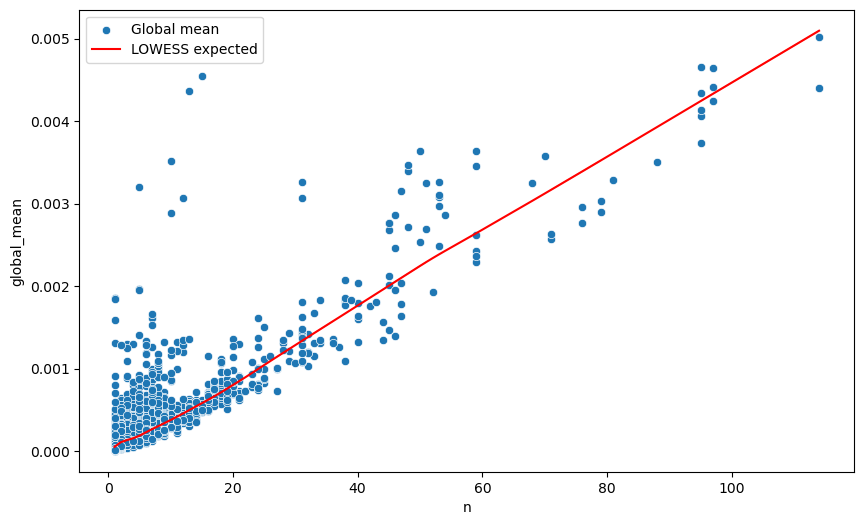

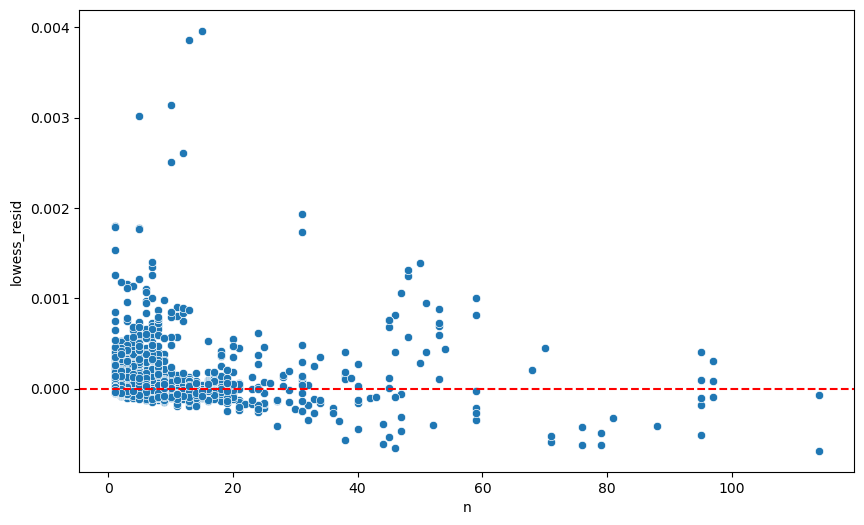

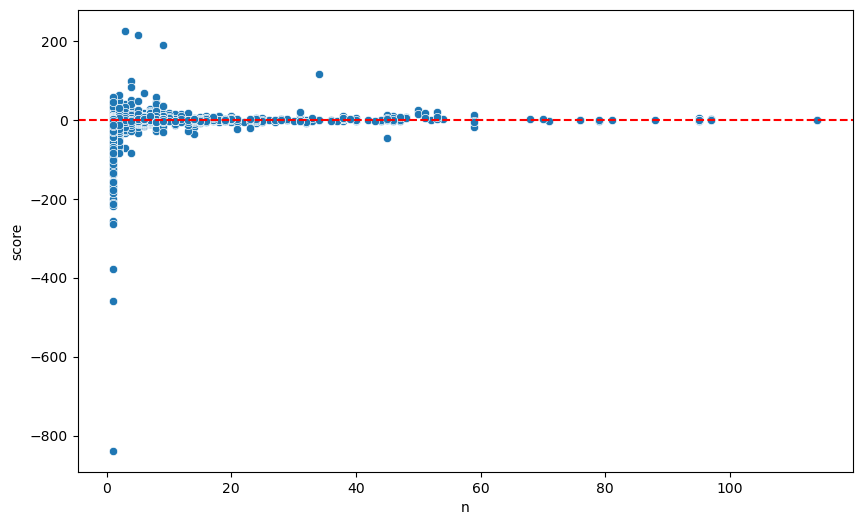

In [122]:
fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(data=df2, x="n", y="global_mean", ax=ax)
sns.lineplot(data=df2, x="n", y="lowess_expected", ax=ax, color='red')
ax.legend(
    handles=[ax.collections[0], ax.lines[0]], 
    labels=["Global mean", "LOWESS expected"], 
    loc="best"
)
plt.show()

fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(data=df2, x="n", y="lowess_resid", ax=ax)
plt.axhline(0, color='red', linestyle='--')
plt.show()

fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(data=df2, x="n", y="score", ax=ax)
plt.axhline(0, color='red', linestyle='--')
plt.show()